### 1_1 - Preprocessing to save one dataset for only geometric info based on query Column

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
data = pd.read_parquet('ds/shopping_queries_dataset_examples.parquet')

In [95]:
#to focus only on one locale like us

data = data[data['product_locale'] == 'us']
data = data.sample(n=50000, random_state=42).reset_index(drop=True)

#data info

print(f"shape: {data.shape}")
print()
print(data.dtypes)

shape: (50000, 9)

example_id         int64
query             object
query_id           int64
product_id        object
product_locale    object
esci_label        object
small_version      int64
large_version      int64
split             object
dtype: object


In [96]:
data.head(2)

,example_id,query,query_id,product_id,product_locale,esci_label,small_version,large_version,split
0,2219601,workout weights,113894,B07HGX6G9K,us,E,1,1,train
1,1452229,nintendo gift cards,73849,B00K59HKIQ,us,I,0,1,train


In [97]:
#drop unessery columns since we don t use other dataset

# and also since we d ont want to use product dataset and our goal is only categorise based on query it self we
# don t need to use esci (exact , , , ....) labelling
data = data.drop(columns=['example_id' , 'product_id' , 'query_id' , 'split' , 'product_locale' ,'esci_label' , 'small_version' , 'large_version'])

In [98]:
data.info()

#we have now only one columns query

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   query   50000 non-null  object
dtypes: object(1)
memory usage: 390.8+ KB


In [99]:
#convert obj to string 

data['query'] = data['query'].astype('string')



In [100]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   query   50000 non-null  string
dtypes: string(1)
memory usage: 390.8 KB


In [101]:
data.isnull().sum()

query    0
dtype: int64

In [ ]:
# new geometrique columns from str columns

data['query_chars'] = data['query'].fillna('').str.len()
data['query_words'] = data['query'].fillna('').str.split().str.len()
#contain a number digit it could define or segment people the one that search for specifique like tv 50 inch 0 or  1
data['contains_digit'] = data['query'].str.contains(r'\d').astype(int)
#count digit
data['digit_count'] = data['query'].str.count(r'\d')

#average word length
data['avg_word_len'] = data['query_chars'] / data['query_words'].replace(0, 1)

#space count
data['space_count'] = data['query'].str.count(' ')

#special cracters count
data['spec_char_count'] = data['query'].str.count(r'[^a-zA-Z0-9\s]')

#upper case ratio no need everything low case
#data['upper_ratio'] = data['query'].str.findall(r'[A-Z]').str.len() / data['query_chars']


#since we are based on just query we tried to extract max info 

In [103]:
data.head(10)

,query,query_chars,query_words,contains_digit,digit_count,avg_word_len,space_count,spec_char_count
0,workout weights,15,2,0,0,7.5,1,0
1,nintendo gift cards,19,3,0,0,6.333333,2,0
2,urban skin rx,13,3,0,0,4.333333,2,0
3,bird seed,9,2,0,0,4.5,1,0
4,+foot cream without alcohol,27,4,0,0,6.75,3,1
5,brother tn730 high yield black toner,36,6,1,3,6.0,5,0
6,60 lashes,9,2,1,2,4.5,1,0
7,cpap filters,12,2,0,0,6.0,1,0
8,long cord lavalier microphone,29,4,0,0,7.25,3,0
9,tumblers bulk wholesale,23,3,0,0,7.666667,2,0


In [104]:
data.describe()

,query_chars,query_words,contains_digit,digit_count,avg_word_len,space_count,spec_char_count
count,50000.0,50000.000000,50000.000000,50000.0,50000.0,50000.0,50000.0
mean,21.50328,3.606420,0.149940,0.2959,6.111051,2.60744,0.06824
std,9.983063,1.750056,0.357016,0.810158,1.382087,1.759386,0.338387
min,1.0,1.000000,0.000000,0.0,1.0,0.0,0.0
25%,15.0,2.000000,0.000000,0.0,5.25,1.0,0.0
50%,20.0,3.000000,0.000000,0.0,6.0,2.0,0.0
75%,27.0,4.000000,0.000000,0.0,6.8,3.0,0.0
max,171.0,29.000000,1.000000,8.0,48.0,29.0,11.0


In [105]:
numeric_cols = ['query_chars', 'query_words', 'contains_digit', 'digit_count' , 'avg_word_len' , 'space_count' , 'spec_char_count']

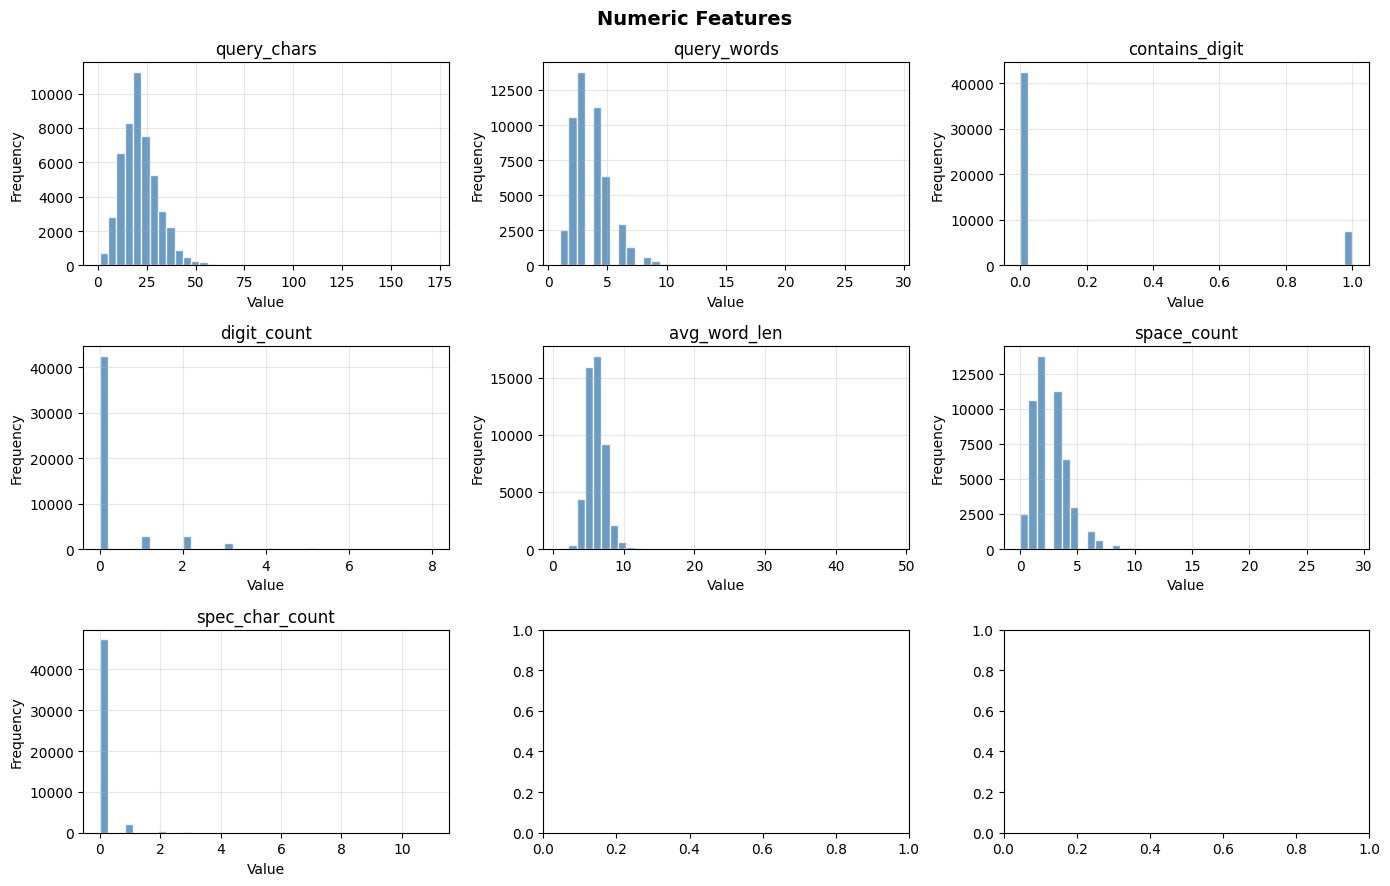

In [106]:
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
fig.suptitle('Numeric Features', fontsize=14, fontweight='bold')

#hist for each numeric columns
for ax, col in zip(axes.flat, numeric_cols):
    ax.hist(data[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



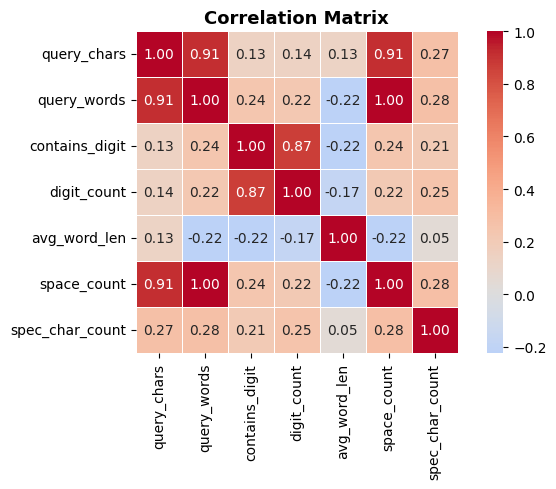

In [107]:
correlation = data[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['query_chars', 'query_words', 'contains_digit', 'digit_count' , 'avg_word_len' , 'space_count' , 'spec_char_count'] 

scaler = StandardScaler()
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])

In [111]:
data.head(5)

,query,query_chars,query_words,contains_digit,digit_count,avg_word_len,space_count,spec_char_count
0,workout weights,-0.651438,-0.917934,-0.419985,-0.365241,1.004975,-0.913646,-0.201665
1,nintendo gift cards,-0.250755,-0.346518,-0.419985,-0.365241,0.160833,-0.345260,-0.201665
2,urban skin rx,-0.851779,-0.346518,-0.419985,-0.365241,-1.286269,-0.345260,-0.201665
3,bird seed,-1.252462,-0.917934,-0.419985,-0.365241,-1.165677,-0.913646,-0.201665
4,+foot cream without alcohol,0.550610,0.224898,-0.419985,-0.365241,0.462312,0.223126,2.753563


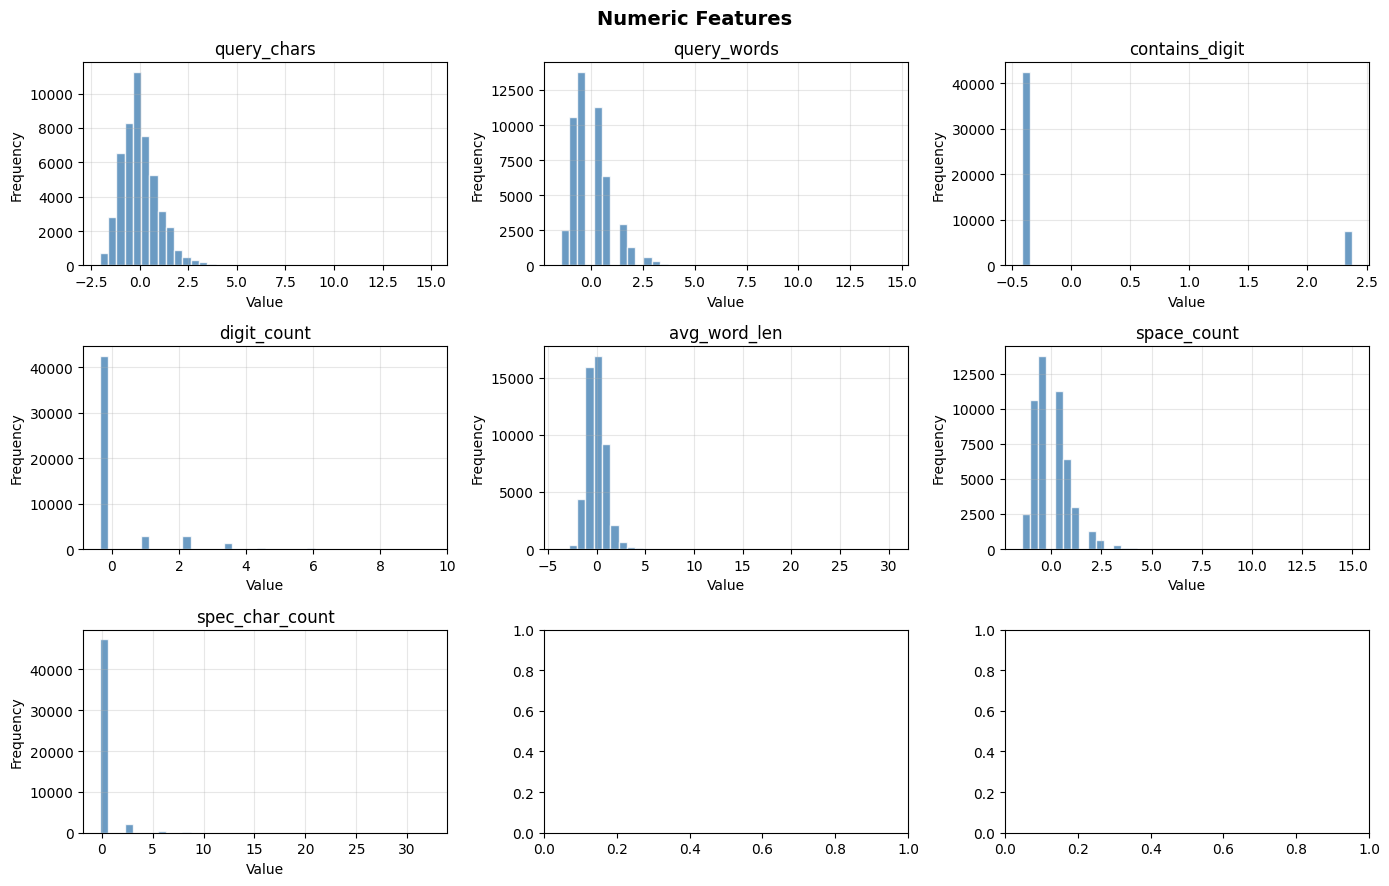

In [114]:
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
fig.suptitle('Numeric Features', fontsize=14, fontweight='bold')

#hist for each numeric columns
for ax, col in zip(axes.flat, numeric_cols):
    ax.hist(data[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [113]:
data.to_csv("ds/cleaned_amazon_queries_dataset_en_50k.csv")